In [65]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Usar o silhouette score como métrica pra avaliar a clusterização e ajudar a definir a quantidade de cluster que o kmeans vai processar
import os

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [81]:
# Nessa parte estou carregando o dataset gerado no notebok 4
caminho_dados = "../data/processed/indice_vulnerabilidade_hidrica.parquet"
df_ivh = pd.read_parquet(caminho_dados)

# Filtrando as features que vão ser usadas
features = ['ivh_normalizado', 'total_eventos', 'media_chuva_mm']
df_cluster = df_ivh[['bairro'] + features].copy()

print(f"Quantidade de bairros: {len(df_cluster)}")
df_cluster

Quantidade de bairros: 37


,bairro,ivh_normalizado,total_eventos,media_chuva_mm
0,SENADOR VASCONCELOS,100.0,1,7.000000
1,BENTO RIBEIRO,91.8,1,7.600000
2,ILHA DE GUARATIBA,82.7,1,8.400000
3,IMPERIAL DE SÃO CRISTÓVÃO,78.8,1,8.800000
4,JARDIM SULACAP,73.5,1,9.400000
5,JARDIM AMÉRICA,68.9,1,10.000000
6,FREGUESIA (JACAREPAGUÁ),68.9,1,10.000000
7,PADRE MIGUEL,62.9,2,10.900000
8,ROCHA,53.9,1,12.600000
9,GUARATIBA,45.1,11,14.890909


In [67]:
# Botando as features no modelo
X = df_cluster[features]

# Ajustando a escala pq o Kmeans é baseado em distância euclidiana, então a escala importa mt e vou ajustar ela com o StandardScaler
# ivh_normalizado vai até 100, eventos são unidades baixas e chuva é em mm
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

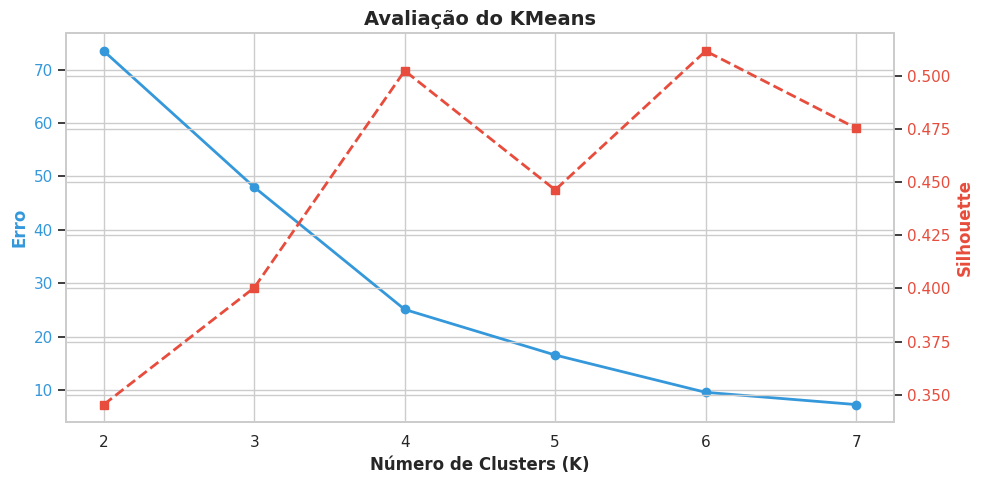

In [68]:
inertias = []
silhouette_scores = []
# Testaremos de 2 a 7 clusters e vamos decidir qual é o melhor valor depois analisando o gráfico (cotovelo e silhouette)
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo da esquerda: Erro (Soma das distâncias de cada ponto ao seu cluster)
cor_erro = '#3498db'
ax1.set_xlabel('Número de Clusters (K)', fontweight='bold')
ax1.set_ylabel('Erro', color=cor_erro, fontweight='bold')
ax1.plot(K_range, inertias, marker='o', color=cor_erro, linewidth=2)
ax1.tick_params(axis='y', labelcolor=cor_erro)

# Eixo da direita: Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette', color='#e74c3c', fontweight='bold')
ax2.plot(K_range, silhouette_scores, marker='s', color='#e74c3c', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title("Avaliação do KMeans", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [69]:
# Como o cotovelo e o pico do silhoeutte estão ao mesmo tempo em 4, isso mostra que o ideal é utilizar 4 como sendo o número de cluster
# Dessa forma, vamos aplicar o Kmeans para separar os bairros em 4 grupos
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

In [70]:
# O tão famigerado momento de interpretar os centroides
resumo_clusters = df_cluster.groupby('cluster')[features].mean().round(2)
resumo_clusters['qtd_bairros'] = df_cluster.groupby('cluster').size()

# Ajeitando as colunas para a leitura ficar melhor
resumo_clusters = resumo_clusters[['qtd_bairros', 'ivh_normalizado', 'total_eventos', 'media_chuva_mm']]
display(resumo_clusters)

# Função auxiliar para o relatório: mapear quais bairros caíram em cada grupo
print("\nBairros que estão em cada custler:")
for c in range(K_FINAL):
    bairros = df_cluster[df_cluster['cluster'] == c]['bairro'].tolist()
    print(f"\nCluster {c} ({len(bairros)} bairros):")
    print(", ".join(bairros))

,qtd_bairros,ivh_normalizado,total_eventos,media_chuva_mm
cluster,,,,
0,21,24.72,1.43,31.33
1,4,2.50,1.00,134.20
2,9,75.71,1.11,9.41
3,3,40.83,7.00,16.66



Bairros que estão em cada custler:

Cluster 0 (21 bairros):
PECHINCHA, SENADOR CAMARÁ, SEPETIBA, ENCANTADO, CIDADE DE DEUS, IRAJÁ, PACIÊNCIA, ANCHIETA, REALENGO, BOTAFOGO, VILA ISABEL, CASCADURA, JACAREPAGUÁ, PIEDADE, TANQUE, MAGALHÃES BASTOS, CENTRO, TIJUCA, PENHA CIRCULAR, MARECHAL HERMES, BARRA DA TIJUCA

Cluster 1 (4 bairros):
MARACANÃ, BANGU, RIO COMPRIDO, RECREIO DOS BANDEIRANTES

Cluster 2 (9 bairros):
SENADOR VASCONCELOS, BENTO RIBEIRO, ILHA DE GUARATIBA, IMPERIAL DE SÃO CRISTÓVÃO, JARDIM SULACAP, JARDIM AMÉRICA, FREGUESIA (JACAREPAGUÁ), PADRE MIGUEL, ROCHA

Cluster 3 (3 bairros):
GUARATIBA, CAMPO GRANDE, SANTA CRUZ


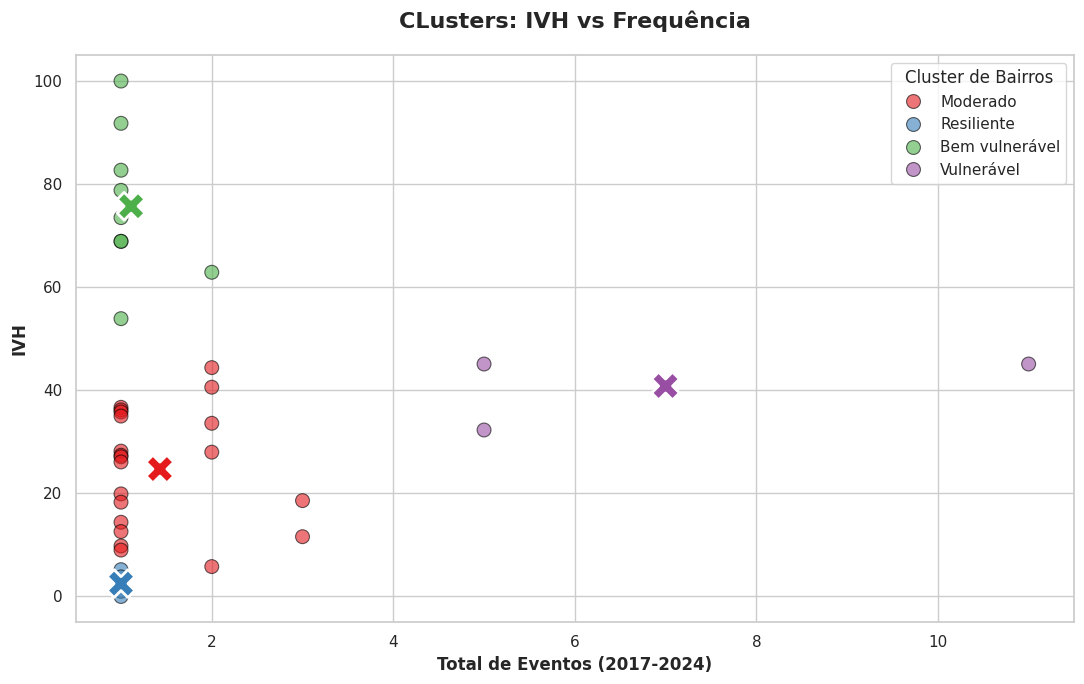

In [78]:
# O KMeans treinou nos dados escalonados, então vou reverter para mm e unidades
centroides_escalonados = kmeans_final.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_escalonados)

# Pra facilitar o plot, criei um df para os centroides
df_centroides = pd.DataFrame(centroides_originais, columns=features)
df_centroides['cluster'] = range(K_FINAL)

# 2. Configurar a visualização
plt.figure(figsize=(11, 7))
PALETA = 'Set1' # Uma paleta qualitativa clara

# Plotando os Bairros
sns.scatterplot(
    data=df_cluster,
    x='total_eventos',
    y='ivh_normalizado',
    hue='cluster',
    palette=PALETA,
    s=100,
    alpha=0.6,        # Aqui botei uma transparência só pra ficar mais fácil de ver a sobreposição
    edgecolor='black',
    legend='full'
)

# Plotando os centroides
# Vou marcar eles como sendo vários X
sns.scatterplot(
    data=df_centroides,
    x='total_eventos',
    y='ivh_normalizado',
    hue='cluster',
    palette=PALETA,
    s=400,
    marker='X',
    edgecolor='white',
    linewidth=2,
    legend=False
)

plt.title("CLusters: IVH vs Frequência", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Total de Eventos (2017-2024)", fontweight='bold', fontsize=12)
plt.ylabel("IVH", fontweight='bold', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Moderado', 'Resiliente', 'Bem vulnerável', 'Vulnerável']
plt.legend(handles, labels, title="Cluster de Bairros", title_fontsize='12', fontsize='11', loc='best')
plt.tight_layout()

# Pra salvar a foto
os.makedirs("../figuras", exist_ok=True)
plt.savefig("../figuras/kmeans_perfis_foco_vulnerabilidade.png", dpi=150, bbox_inches='tight')

plt.show()